In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Cleaning Data

In [2]:
# โหลดและทำความสะอาดข้อมูล
df = pd.read_csv("NASDAQ_100_Data_From_2010.csv", sep="\t")
df["Date"] = pd.to_datetime(df["Date"])

price_matrix = df.pivot(index="Date", columns="Name", values="Adj Close")
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]
clean_returns = returns_matrix.dropna(axis=1)

# Standardization (แต่ยังไม่ Transpose)
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns)

stock_names = clean_returns.columns.tolist()

print("Initial Data Shape:", X.shape)
print(f"Stocks: {len(stock_names)}, Trading Days: {X.shape[0]}")

Initial Data Shape: (2942, 82)
Stocks: 82, Trading Days: 2942


#  PATH 1: Original Data (ไม่ผ่าน PCA)

In [3]:
print("\n" + "=" * 60)
print("PATH 1: Original Data (X_matrix)")
print("=" * 60)

# Transpose เพื่อให้หุ้นเป็น Samples
X_matrix = X.T  #

print(f"X_matrix shape: {X_matrix.shape}")
print(f"(หุ้น={X_matrix.shape[0]}, วัน={X_matrix.shape[1]})")

results = {
    "stock_names": stock_names,
    "X_matrix": X_matrix,
    "clean_returns": clean_returns,
    "scaler": scaler
}


PATH 1: Original Data (X_matrix)
X_matrix shape: (82, 2942)
(หุ้น=82, วัน=2942)



PATH 2: PCA Reduction (X_PCA)
X_matrix (ต้นฉบับ) shape: (82, 2942)
X_PCA (หลังผ่าน PCA) shape: (82, 69)
จำนวน Components: 69
Cumulative Variance Explained: 0.9543
Dimensionality reduction: 2942 → 69


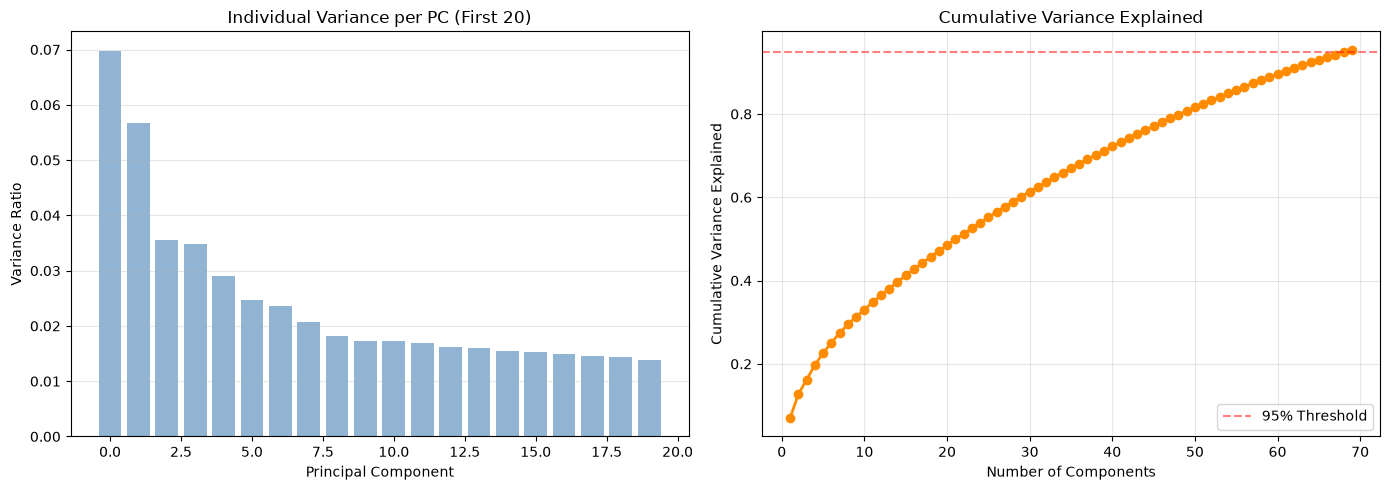

In [4]:
print("\n" + "=" * 60)
print("PATH 2: PCA Reduction (X_PCA)")
print("=" * 60)

#  FIX: ทำ PCA บน X_matrix (82 หุ้น, 2942 วัน)
pca = PCA(n_components=0.95, random_state=42)
X_PCA = pca.fit_transform(X_matrix)

n_components = X_PCA.shape[1]
cum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"X_matrix (ต้นฉบับ) shape: {X_matrix.shape}")
print(f"X_PCA (หลังผ่าน PCA) shape: {X_PCA.shape}")
print(f"จำนวน Components: {n_components}")
print(f"Cumulative Variance Explained: {cum_var[-1]:.4f}")
print(f"Dimensionality reduction: {X_matrix.shape[1]} → {X_PCA.shape[1]}")

results["pca_model"] = pca
results["X_PCA"] = X_PCA

# Plot: PCA Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot - Individual variance
ax1.bar(range(len(pca.explained_variance_ratio_[:20])),
        pca.explained_variance_ratio_[:20],
        alpha=0.6, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Ratio')
ax1.set_title('Individual Variance per PC (First 20)')
ax1.grid(axis='y', alpha=0.3)

# Line plot - Cumulative variance
ax2.plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='darkorange', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% Threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ทำt-SNE บน PATH 1 (X_matrix)

In [5]:
print("\n" + "=" * 60)
print("STEP 4.1: t-SNE บน X_matrix (Original Data)")
print("=" * 60)

tsne_1 = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
tsne_X_matrix = tsne_1.fit_transform(X_matrix)

tsne_X_matrix_df = pd.DataFrame(
    tsne_X_matrix,
    columns=["Dim1", "Dim2"],
    index=stock_names
)

results["tsne_X_matrix"] = tsne_X_matrix_df

print("t-SNE (X_matrix) - ตัวอย่าง:")
print(tsne_X_matrix_df.head())
print(f"Shape: {tsne_X_matrix_df.shape}")


STEP 4.1: t-SNE บน X_matrix (Original Data)
t-SNE (X_matrix) - ตัวอย่าง:
          Dim1      Dim2
AAPL  0.099730 -1.129269
ADBE -0.356525  0.779014
ADI   1.732301 -0.732467
ADP   1.361277  3.031380
ADSK -0.176319  0.537067
Shape: (82, 2)


# ทำt-SNE บน PATH 2 (X_PCA)

In [6]:
print("\n" + "=" * 60)
print("STEP 4.2: t-SNE บน X_PCA (After PCA)")
print("=" * 60)

tsne_2 = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
tsne_X_PCA = tsne_2.fit_transform(X_PCA)

tsne_X_PCA_df = pd.DataFrame(
    tsne_X_PCA,
    columns=["Dim1", "Dim2"],
    index=stock_names
)

results["tsne_X_PCA"] = tsne_X_PCA_df

print("t-SNE (X_PCA) - ตัวอย่าง:")
print(tsne_X_PCA_df.head())
print(f"Shape: {tsne_X_PCA_df.shape}")


STEP 4.2: t-SNE บน X_PCA (After PCA)
t-SNE (X_PCA) - ตัวอย่าง:
          Dim1      Dim2
AAPL  2.024563 -1.974993
ADBE  2.013814 -1.087343
ADI   0.866368 -2.055114
ADP   0.506879  0.413145
ADSK  2.003108 -1.284070
Shape: (82, 2)


# VISUALIZATION: เปรียบเทียบ t-SNE ทั้ง 2 Path

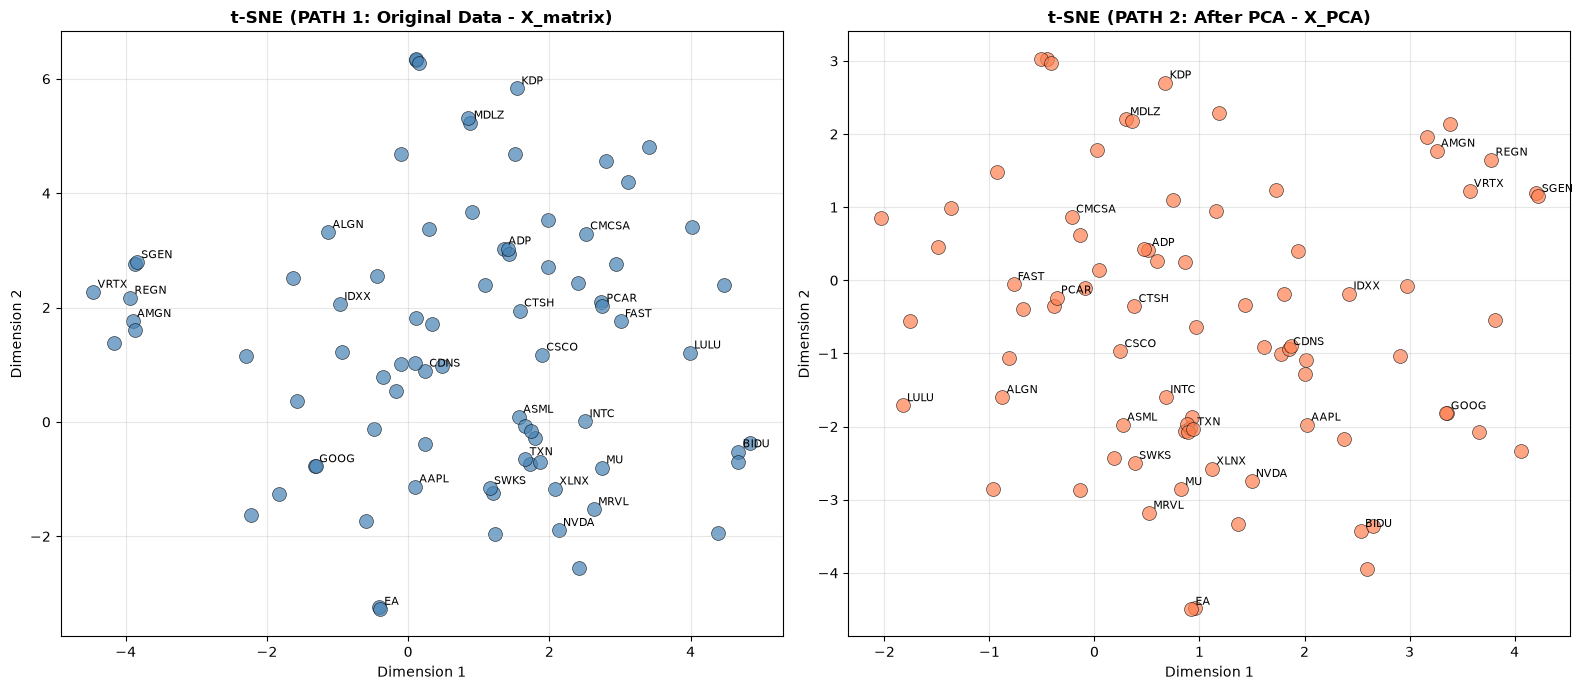

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Path 1: Original
axes[0].scatter(tsne_X_matrix_df["Dim1"], tsne_X_matrix_df["Dim2"],
                s=100, alpha=0.7, c='steelblue', edgecolors='black', linewidth=0.5)
for ticker in stock_names[::3]:
    idx = stock_names.index(ticker)
    axes[0].annotate(ticker,
                     (tsne_X_matrix_df.iloc[idx, 0], tsne_X_matrix_df.iloc[idx, 1]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")

axes[0].set_title("t-SNE (PATH 1: Original Data - X_matrix)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")
axes[0].grid(alpha=0.3)

# Path 2: PCA
axes[1].scatter(tsne_X_PCA_df["Dim1"], tsne_X_PCA_df["Dim2"],
                s=100, alpha=0.7, c='coral', edgecolors='black', linewidth=0.5)
for ticker in stock_names[::3]:
    idx = stock_names.index(ticker)
    axes[1].annotate(ticker,
                     (tsne_X_PCA_df.iloc[idx, 0], tsne_X_PCA_df.iloc[idx, 1]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")

axes[1].set_title("t-SNE (PATH 2: After PCA - X_PCA)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()